## Environment


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance, ks_2samp
from scipy import stats
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

def plot_results(images, nrow=10, title=None):
    images = (images.cpu().detach().clone() * 0.5 + 0.5).clamp(0, 1)
    grid = torchvision.utils.make_grid(images, nrow=nrow, padding=1, normalize=False)
    plt.figure(figsize=(10, (images.size(0) // nrow + 1) * 1.0), dpi=300)
    np_grid = grid.permute(1, 2, 0).numpy()
    plt.imshow(np_grid)
    plt.axis("off")
    if title is not None:
        plt.title(title, fontsize=16)
    plt.show()

Using device: cuda


## VAE Model

In [ ]:
class PreActResidualBlock(nn.Module):
    """Pre-activation ResBlock: GN -> SiLU -> Conv -> GN -> SiLU -> Conv + shortcut."""
    def __init__(self, in_channels, out_channels, groups=8, dropout=0.1):
        super().__init__()
        self.gn1 = nn.GroupNorm(groups, in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)

        self.gn2 = nn.GroupNorm(groups, out_channels)
        self.act2 = nn.SiLU()
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)

        self.shortcut = (
            nn.Conv2d(in_channels, out_channels, 1, bias=False)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        out = self.conv1(self.act1(self.gn1(x)))
        out = self.conv2(self.dropout(self.act2(self.gn2(out))))
        return out + self.shortcut(x)


class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128, img_channels=1, groups=8, dropout=0.1,
                 out_activation="tanh"):  # out_activation: "tanh" or "sigmoid"
        super().__init__()
        self.latent_dim = latent_dim
        self.img_channels = img_channels
        self.out_activation = out_activation

        # ----------------
        # Encoder: 28 -> 14 -> 7 -> 4
        # ----------------
        self.enc = nn.Sequential(
            # 28 -> 14
            nn.Conv2d(img_channels, 32, 3, stride=2, padding=1, bias=False),
            PreActResidualBlock(32, 32, groups=groups, dropout=dropout),

            # 14 -> 7
            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False),
            PreActResidualBlock(64, 64, groups=groups, dropout=dropout),

            # 7 -> 4
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False),
            PreActResidualBlock(128, 128, groups=groups, dropout=dropout),
        )
        self.mid = PreActResidualBlock(128, 128, groups=groups, dropout=dropout)

        self.flatten_dim = 128 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # ----------------
        # Decoder: z -> 4x4 -> 7 -> 14 -> 28
        # ----------------
        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        self.dec1 = nn.Sequential(
            # 4 -> 7  (k=3,s=2,p=1 gives 7)
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=0, bias=False),
            nn.GroupNorm(groups, 64),
            nn.SiLU(),
            PreActResidualBlock(64, 64, groups=groups, dropout=dropout),
        )
        self.dec2 = nn.Sequential(
            # 7 -> 14
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1, bias=False),
            nn.GroupNorm(groups, 32),
            nn.SiLU(),
            PreActResidualBlock(32, 32, groups=groups, dropout=dropout),
        )
        self.dec3 = nn.Sequential(
            # 14 -> 28
            nn.ConvTranspose2d(32, 32, 4, stride=2, padding=1, bias=False),
            nn.GroupNorm(groups, 32),
            nn.SiLU(),
        )
        self.out_conv = nn.Conv2d(32, img_channels, 3, padding=1)

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if getattr(m, 'bias', None) is not None:
                nn.init.zeros_(m.bias)
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def encode(self, x):
        h = self.enc(x)
        h = self.mid(h)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 128, 4, 4)
        h = self.dec1(h)
        h = self.dec2(h)
        h = self.dec3(h)
        h = self.out_conv(h)
        if self.out_activation == "sigmoid":
            return torch.sigmoid(h)
        else:
            return torch.tanh(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


## Loss Function & Training Script

In [ ]:
def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):
    recon_loss =
    kld =
    return recon_loss + beta * kld, recon_loss, kld


def train_conv_vae(vae, train_loader, epochs=20, device='cuda', beta=1.0, lr=1e-3):
    vae = vae.to(device)
    optimizer = torch.optim.AdamW(vae.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    print("Training Convolutional VAE...")
    print(f"Model parameters: {sum(p.numel() for p in vae.parameters()):,}")

    for epoch in range(epochs):
        vae.train()
        train_loss = 0
        train_recon = 0
        train_kld = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for batch_idx, (data, _) in enumerate(pbar):
            data = data.to(device)
            optimizer.zero_grad()

            recon_batch, mu, logvar = vae(data)
            loss, recon_loss, kld = vae_loss_function(recon_batch, data, mu, logvar, beta)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            train_recon += recon_loss.item()
            train_kld += kld.item()

            pbar.set_postfix({
                'loss': f'{loss.item()/len(data):.2f}',
                'recon': f'{recon_loss.item()/len(data):.2f}',
                'kld': f'{kld.item()/len(data):.2f}'
            })

        n_samples = len(train_loader.dataset)
        avg_loss = train_loss / n_samples
        avg_recon = train_recon / n_samples
        avg_kld = train_kld / n_samples

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        print(f'Epoch {epoch+1}/{epochs}:')
        print(f'  Total Loss: {avg_loss:.4f}')
        print(f'  Recon Loss: {avg_recon:.4f}')
        print(f'  KLD Loss:   {avg_kld:.4f}')
        print(f'  LR:         {current_lr:.6f}')

    return vae

## Load MNIST Dataset

In [ ]:
print("="*60)
print("STEP 1: Loading MNIST Dataset")
print("="*60)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          num_workers=4, pin_memory=True)

print(f"Dataset loaded: {len(train_dataset)} training images")

STEP 1: Loading MNIST Dataset


100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]

Dataset loaded: 60000 training images


## Train and Save the Model

In [ ]:
print("\n" + "="*60)
print("STEP 2: Training Convolutional VAE")
print("="*60)

latent_dim = 128
vae = ConvVAE(latent_dim=latent_dim, img_channels=1)
beta = 3
vae = train_conv_vae(vae, train_loader, epochs=40, device=device, beta=beta, lr=1e-3)

torch.save({
    'model_state_dict': vae.state_dict(),
    'latent_dim': latent_dim,
}, f'conv_vae_checkpoint_{beta}.pt')
print("\n✓ VAE checkpoint saved!")


STEP 2: Training Convolutional VAE
Training Convolutional VAE...
Model parameters: 1,780,545


Epoch 1/40: 100%|██████████| 469/469 [00:08<00:00, 53.43it/s, loss=132.39, recon=90.13, kld=14.09]


Epoch 1/40:
  Total Loss: 2943.1498
  Recon Loss: 121.7197
  KLD Loss:   940.4768
  LR:         0.000998


Epoch 2/40: 100%|██████████| 469/469 [00:06<00:00, 67.28it/s, loss=112.49, recon=71.13, kld=13.79]


Epoch 2/40:
  Total Loss: 122.1088
  Recon Loss: 77.7753
  KLD Loss:   14.7778
  LR:         0.000994


...

Epoch 38/40:
  Total Loss: 90.3192
  Recon Loss: 44.7839
  KLD Loss:   15.1784
  LR:         0.000006


Epoch 39/40: 100%|██████████| 469/469 [00:06<00:00, 68.99it/s, loss=88.95, recon=43.57, kld=15.13]


Epoch 39/40:
  Total Loss: 90.2579
  Recon Loss: 44.7357
  KLD Loss:   15.1741
  LR:         0.000002


Epoch 40/40: 100%|██████████| 469/469 [00:06<00:00, 68.30it/s, loss=96.90, recon=50.91, kld=15.33]


Epoch 40/40:
  Total Loss: 90.1953
  Recon Loss: 44.6755
  KLD Loss:   15.1733
  LR:         0.000000

✓ VAE checkpoint saved!


## Visualize Reconstruction

Visualizing VAE Reconstruction


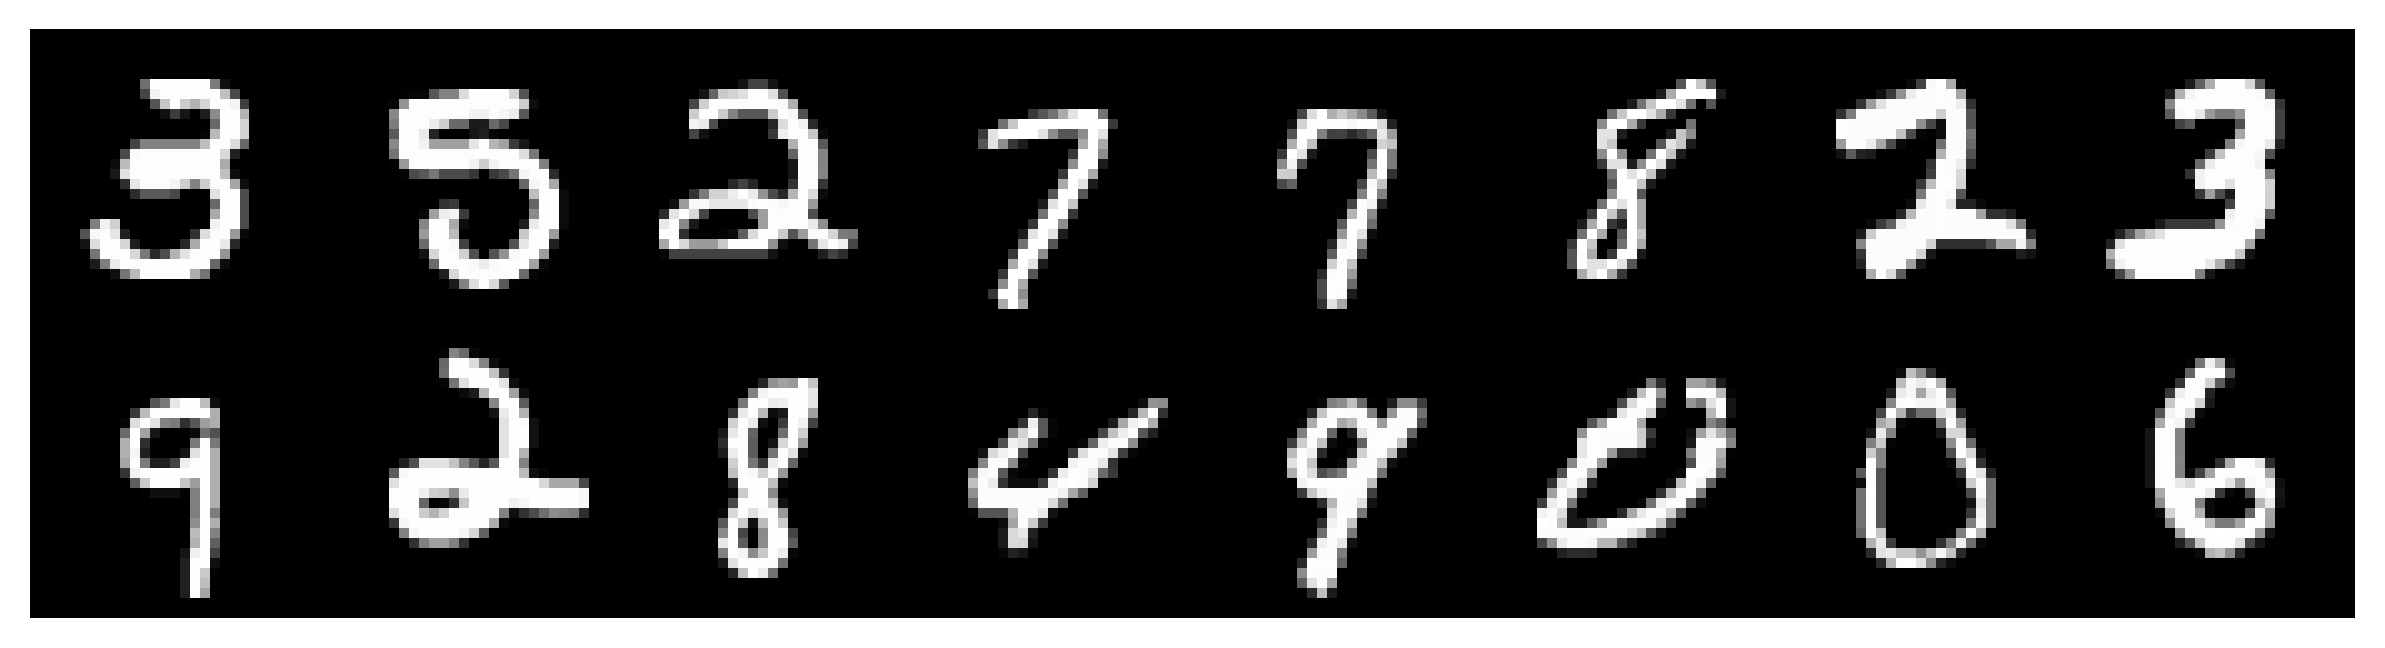

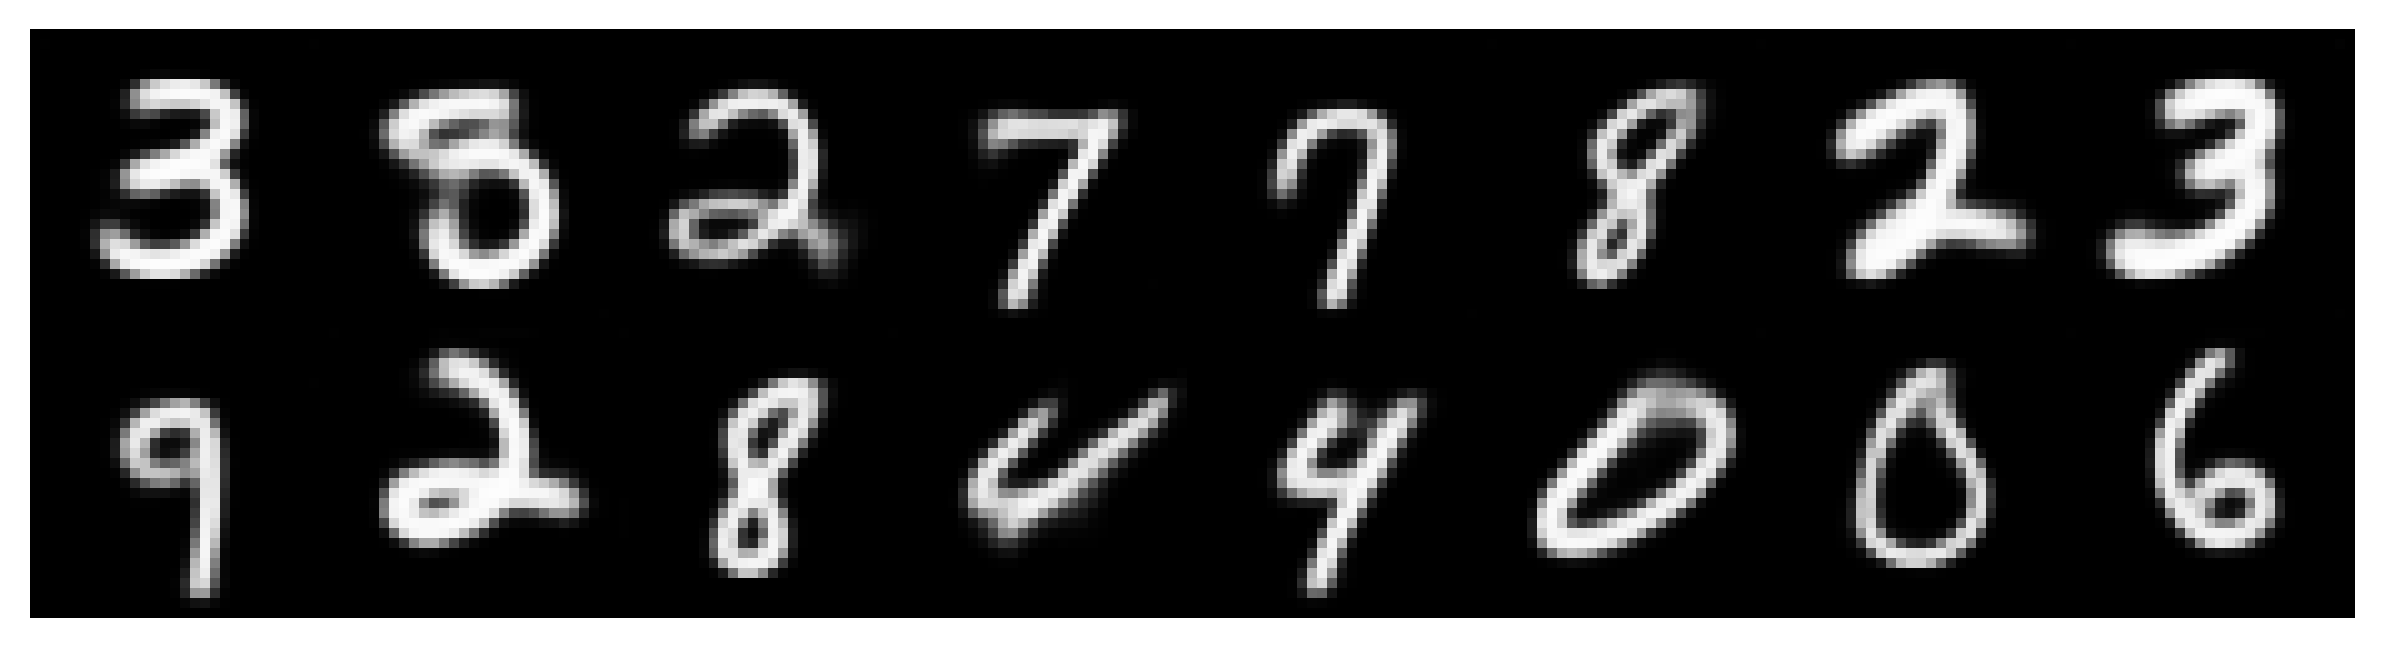

In [ ]:
print("="*60)
print("Visualizing VAE Reconstruction")
print("="*60)

vae.eval()
with torch.no_grad():
    test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

    data, _ = next(iter(test_loader))
    data = data.to(device)

    recon, mu, logvar = vae(data)

    plot_results(data, nrow=8)
    plot_results(recon, nrow=8)

## Visualize Generation

Visualizing Random Generation from Latent Space


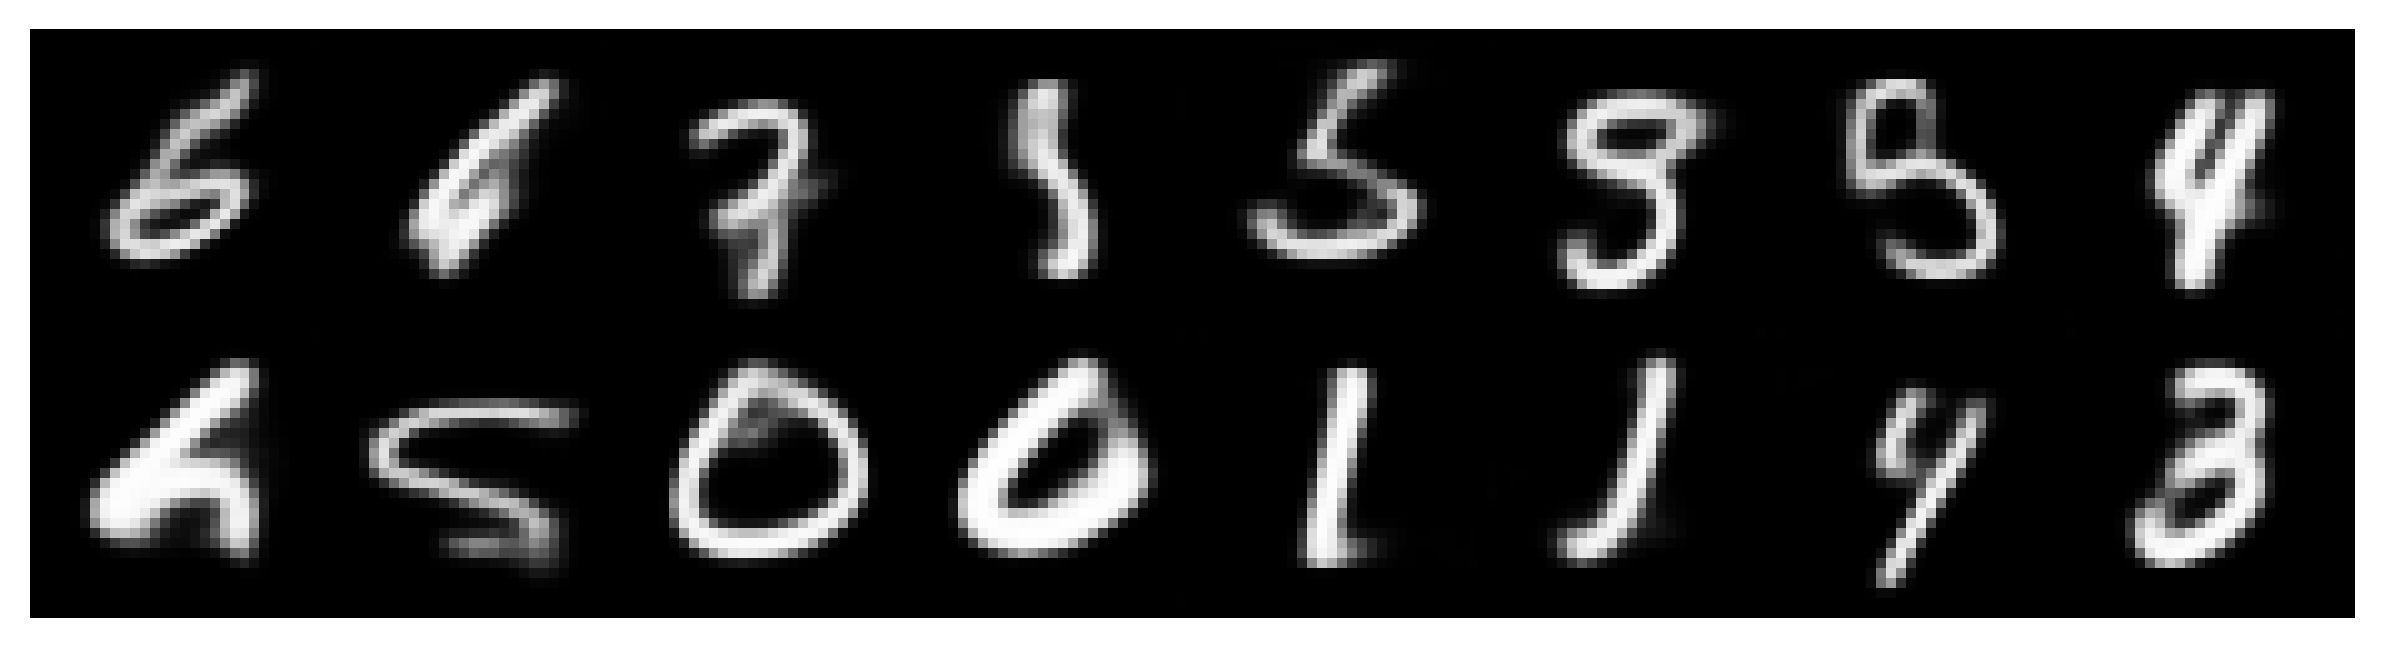

In [ ]:
print("="*60)
print("Visualizing Random Generation from Latent Space")
print("="*60)

vae.eval()
with torch.no_grad():
    n_samples = 16
    z = torch.randn(n_samples, latent_dim).to(device)

    generated = vae.decode(z)
    generated_np = generated.cpu().numpy()

    plot_results(generated, nrow=8)